In [ ]:
import os
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set project path
project_path = '/content/drive/MyDrive/EE541-project'
os.chdir(project_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
# Load the datat
movies_train_df = pd.read_csv('movies_train_new.csv')[:3500]
movies_test_df = pd.read_csv('movies_test_new.csv')[:1500]
movies_train_df = movies_train_df[movies_train_df['vote_count'] != 0]
movies_test_df = movies_test_df[movies_test_df['vote_count'] != 0]
movies_train_df = movies_train_df.dropna(subset=['vote_average'])
movies_test_df = movies_test_df.dropna(subset=['vote_average'])
movies_test_df[:5]

,id,budget,revenue,popularity,genres,keywords,original_title,overview,production_companies,production_countries,spoken_languages,tagline,cast,crew,vote_average,vote_count
0,153035,0,0.0,0.059216,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...","[{'id': 208612, 'name': 'poliziotteschi'}, {'i...",Provincia violenta,"Franco Sereni, a captain of carabiniers, is di...",[],"[{'iso_3166_1': 'IT', 'name': 'Italy'}]","[{'iso_639_1': 'it', 'name': 'Italiano'}]",NaN,"[{'cast_id': 1, 'character': 'Sereni', 'credit...","[{'credit_id': '57acde93c3a3682f1800169f', 'de...",4.0,2.0
1,63888,0,0.0,0.783968,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",[],Mayerling,Crown Prince Rudolf of Austria (Omar Sharif) c...,"[{'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8...",[],"[{'iso_639_1': 'en', 'name': 'English'}]",NaN,"[{'cast_id': 2, 'character': 'Archduke Rudolf'...","[{'credit_id': '52fe46bfc3a368484e0a1b89', 'de...",6.6,5.0
2,316152,50000000,25035950.0,10.223582,"[{'id': 10752, 'name': 'War'}, {'id': 28, 'nam...","[{'id': 2831, 'name': 'slavery'}, {'id': 17958...",Free State of Jones,"In 1863, Mississippi farmer Newt Knight serves...","[{'name': 'Larger Than Life Productions', 'id'...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Based on the incredible true story.,"[{'cast_id': 0, 'character': 'Newton Knight', ...","[{'credit_id': '585122c192514175ad009aba', 'de...",6.6,439.0
3,124459,30000000,27437881.0,9.385769,"[{'id': 35, 'name': 'Comedy'}]","[{'id': 2343, 'name': 'magic'}, {'id': 14570, ...",The Incredible Burt Wonderstone,After breaking up with his longtime stage part...,"[{'name': 'New Line Cinema', 'id': 12}, {'name...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",Abracatastic!,"[{'cast_id': 5, 'character': 'Burt Wonderstone...","[{'credit_id': '52fe4aacc3a368484e16101b', 'de...",5.3,732.0
4,45220,0,0.0,1.718128,"[{'id': 18, 'name': 'Drama'}, {'id': 10752, 'n...","[{'id': 236, 'name': 'suicide'}, {'id': 836, '...",This Land Is Mine,"In a Nazi-occupied French town, meek and mild-...","[{'name': 'RKO Radio Pictures', 'id': 6}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",A soft-spoken school teacher tries to prove he...,"[{'cast_id': 6, 'character': 'Albert Lory', 'c...","[{'credit_id': '53ca517c0e0a264750001fb0', 'de...",6.6,11.0


In [ ]:
import json
import ast

def to_list(df, feature_names_list):
    """
    Convert JSON-like columns into Python lists, remove `id`, and keep only `name`.
    Handles special cases for `crew` and `cast` columns, limits their size, and cleans up data.

    Args:
        df (pd.DataFrame): Input DataFrame.
        feature_names_list (list): List of feature names to process.

    Returns:
        pd.DataFrame: Processed DataFrame.
    """
    for feature_name in feature_names_list:
        print("Processing feature:", feature_name)

        # STEP 1: Convert JSON format to Python lists safely
        def safe_json_load(x):
            try:
        # If x is a string, attempt to parse it as JSON
                if isinstance(x, str):
                    x = x.replace("'", '"')  # Replace single quotes with double quotes
                    return json.loads(x)
        # If x is already a list (e.g., a Python object), return it as is
                elif isinstance(x, list):
                    return x
                else:
                    return []  # Default to an empty list for other types
            except json.JSONDecodeError:
                try:
            # Use ast.literal_eval as a fallback for malformed JSON strings
                    return ast.literal_eval(x.replace("'", '"'))
                except (ValueError, SyntaxError):
                    return []

        df[feature_name] = df[feature_name].apply(safe_json_load)

        # STEP 2: Special handling for crew and cast columns
        if feature_name == 'crew':  # Limit to most influential crew members
            for index, crew in zip(df.index, df[feature_name]):
                #print(f"Raw crew data: {crew}"
                target_jobs = ['Director', 'Editor', 'Cinematography', 'Writer', 'Music']
                limited_crew = [
                    member["name"] for member in crew
                    if isinstance(member, dict) and "name" in member and "job" in member and member["job"] in target_jobs
                ]
                df.at[index, feature_name] = limited_crew

        elif feature_name == 'cast':  # Limit to top 5 cast members
            for index, cast in zip(df.index, df[feature_name]):
                limited_cast = []
                limit = min(len(cast), 5)  # Max limit of 5 cast members
                for j in range(limit):
                    if "name" in cast[j]:  # Check if 'name' exists in the entry
                        limited_cast.append(cast[j]["name"])
                df.at[index, feature_name] = limited_cast

        else:  # General case: Remove `id` and keep only `name`
            df[feature_name] = df[feature_name].apply(
                lambda x: [item["name"] for item in x if "name" in item]
            )

        # STEP 3: Sort the lists
        df[feature_name] = df[feature_name].apply(
            lambda x: sorted(x) if isinstance(x, list) else ['']
        )

        # STEP 4: Handle empty lists and None values
        df[feature_name] = df[feature_name].apply(
            lambda x: x if len(x) > 0 else ['']
        )

    return df

movies_train = to_list(movies_train_df, ['genres', 'keywords', 'production_companies','spoken_languages','production_countries','cast','crew'])
movies_test = to_list(movies_test_df,  ['genres', 'keywords', 'production_companies','spoken_languages','production_countries','cast','crew'])
# Select the columns you want
movies_train_df_selected = movies_train[['genres', 'keywords', 'production_companies', 'spoken_languages','production_countries','cast','crew']]
movies_test_df_selected = movies_test[['genres', 'keywords', 'production_companies', 'spoken_languages','production_countries','cast','crew']]
movies_test[:5]

Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew
Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew


,id,budget,revenue,popularity,genres,keywords,original_title,overview,production_companies,production_countries,spoken_languages,tagline,cast,crew,vote_average,vote_count
0,153035,0,0.0,0.059216,"[Action, Crime, Drama]","[eurocrime, poliziotteschi]",Provincia violenta,"Franco Sereni, a captain of carabiniers, is di...",[],[Italy],[Italiano],NaN,"[Al Cliver, Alicia Leoni, Antonella Dogan, Cal...","[Mario Bianchi, Mario Bianchi, Maurizio Tedesc...",4.0,2.0
1,63888,0,0.0,0.783968,"[Drama, Romance]",[],Mayerling,Crown Prince Rudolf of Austria (Omar Sharif) c...,[Metro-Goldwyn-Mayer (MGM)],[],[English],NaN,"[Ava Gardner, Catherine Deneuve, James Mason, ...","[Claude Anet, Terence Young]",6.6,5.0
2,316152,50000000,25035950.0,10.223582,"[Action, Drama, History, Thriller, War]","[american civil war, slavery]",Free State of Jones,"In 1863, Mississippi farmer Newt Knight serves...","[Larger Than Life Productions, Route One Films...",[United States of America],"[Deutsch, English]",Based on the incredible true story.,"[Gugu Mbatha-Raw, Jacob Lofland, Keri Russell,...","[Gary Ross, Gary Ross, Juliette Welfling, Nich...",6.6,439.0
3,124459,30000000,27437881.0,9.385769,[Comedy],"[las vegas, magic]",The Incredible Burt Wonderstone,After breaking up with his longtime stage part...,"[Benderspink, Carousel Productions, New Line C...",[United States of America],[English],Abracatastic!,"[James Gandolfini, Jim Carrey, Olivia Wilde, S...","[Chad Kultgen, Don Scardino, John Francis Dale...",5.3,732.0
4,45220,0,0.0,1.718128,"[Drama, War]","[air raid, bravery, cigarette smoking, hand gr...",This Land Is Mine,"In a Nazi-occupied French town, meek and mild-...","[Jean-Renoir- Dudly Nichols Productions, RKO R...",[United States of America],"[Deutsch, English, Latin]",A soft-spoken school teacher tries to prove he...,[],[],6.6,11.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_list(df, column_name):
    """
    Generate a sorted list of unique feature values from a specified column, based on their associated average ratings.

    Args:
        df (pd.DataFrame): Input DataFrame.
        column_name (str): Name of the column to process.

    Returns:
        list: Sorted list of feature names from lowest to highest average rating.
    """
    # Step 1: Track all ratings associated with each feature in a dictionary
    rating_dict = {}
    for _, row in df.iterrows():
        features = row[column_name]
        for feature in features:
            if feature not in rating_dict:
                rating_dict[feature] = (row['vote_average'], 1)
            else:
                rating_dict[feature] = (
                    rating_dict[feature][0] + row['vote_average'],
                    rating_dict[feature][1] + 1,
                )

    # Step 2: Calculate average ratings for each feature
    for feature in rating_dict:
        total_rating, count = rating_dict[feature]
        rating_dict[feature] = total_rating / count

    # Step 3: Create and sort a list of tuples (average rating, feature name)
    sorted_features = sorted((rating, feature) for feature, rating in rating_dict.items())

    # Step 4: Separate feature names and ratings into individual lists
    feature_list = [feature for _, feature in sorted_features]
    ratings_list = [rating for rating, _ in sorted_features]

    return feature_list



# Combine training and testing data
movies_combined_df = pd.concat([movies_train_df, movies_test_df], ignore_index=True)

genres_list = generate_list(movies_combined_df, 'genres')
keywords_list = generate_list(movies_combined_df, 'keywords')
production_companies_list = generate_list(movies_combined_df, 'production_companies')
spoken_languages_list = generate_list(movies_combined_df, 'spoken_languages')
production_countries_list = generate_list(movies_combined_df, 'production_countries')
cast_list = generate_list(movies_combined_df, 'cast')
crew_list = generate_list(movies_combined_df, 'crew')

In [ ]:
def calculate_bin_array(current_features, all_possible_features):
    return [1 if feature in current_features else 0 for feature in all_possible_features]

# Apply to the DataFrame columns
movies_train_df_selected['genres'] = movies_train_df_selected['genres'].apply(lambda x: calculate_bin_array(x, genres_list))
movies_train_df_selected['production_companies'] = movies_train_df_selected['production_companies'].apply(lambda x: calculate_bin_array(x, production_companies_list))
movies_train_df_selected['spoken_languages'] = movies_train_df_selected['spoken_languages'].apply(lambda x: calculate_bin_array(x, spoken_languages_list))
movies_train_df_selected['production_countries'] = movies_train_df_selected['production_countries'].apply(lambda x: calculate_bin_array(x, production_countries_list))
movies_train_df_selected['keywords'] = movies_train_df_selected['keywords'].apply(lambda x: calculate_bin_array(x, keywords_list))
movies_train_df_selected['cast'] = movies_train_df_selected['cast'].apply(lambda x: calculate_bin_array(x, cast_list))
movies_train_df_selected['crew'] = movies_train_df_selected['crew'].apply(lambda x: calculate_bin_array(x, crew_list))

movies_test_df_selected['production_companies'] = movies_test_df_selected['production_companies'].apply(lambda x: calculate_bin_array(x, production_companies_list))
movies_test_df_selected['spoken_languages'] = movies_test_df_selected['spoken_languages'].apply(lambda x: calculate_bin_array(x, spoken_languages_list))
movies_test_df_selected['production_countries'] = movies_test_df_selected['production_countries'].apply(lambda x: calculate_bin_array(x, production_countries_list))
movies_test_df_selected['genres'] = movies_test_df_selected['genres'].apply(lambda x: calculate_bin_array(x, genres_list))
movies_test_df_selected['keywords'] = movies_test_df_selected['keywords'].apply(lambda x: calculate_bin_array(x, keywords_list))
movies_test_df_selected['cast'] = movies_test_df_selected['cast'].apply(lambda x: calculate_bin_array(x, cast_list))
movies_test_df_selected['crew'] = movies_test_df_selected['crew'].apply(lambda x: calculate_bin_array(x, crew_list))


movies_train_df_selected[:10]


<ipython-input-21-0dc530a28c2a>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_train_df_selected['genres'] = movies_train_df_selected['genres'].apply(lambda x: calculate_bin_array(x, genres_list))
<ipython-input-21-0dc530a28c2a>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_train_df_selected['production_companies'] = movies_train_df_selected['production_companies'].apply(lambda x: calculate_bin_array(x, production_companies_list))
<ipython-input-21-0dc530a28c2a>:7: SettingWithCopyWarning:

,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew
0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
keywords = movies_train_df_selected['keywords'][0]
positions = [i for i, val in enumerate(keywords) if val == 1]
movies_test_df_selected[:10]

为 1 的位置是： [1792, 3193, 4705, 4768]


,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew
0,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,"[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,"[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
10,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
def to_concentrations(df, feature_columns, n=10):

    for column in feature_columns:
        print('Processing feature:', column)

        def find_concentration(array):
            """
            Calculate concentration points and the number of '1's in each segment of the array.

            Args:
                array (list): Binary array (contains 0s and 1s).

            Returns:
                list: List of tuples (average position of '1's, count of '1's) for each segment.
            """
            # Divide the array into n segments
            batch_size = len(array) // n
            batches = [array[i:i + batch_size] for i in range(0, len(array), batch_size)]

            concentrations = []
            for batch_index, batch in enumerate(batches):
                total_position = 0
                count_ones = 0

                # Accumulate the positions of '1's in the current batch
                for position_in_batch, value in enumerate(batch):
                    if value == 1:
                        global_position = position_in_batch + batch_index * batch_size  # Adjust for global position
                        total_position += global_position
                        count_ones += 1

                # Calculate the average position if there are '1's in the batch
                if count_ones > 0:
                    average_position = total_position / count_ones
                    concentrations.append((average_position, count_ones))

            return concentrations

        # Apply the concentration calculation to the specified column
        df[column] = df[column].apply(find_concentration)

    return df

movies_train_df_selected = to_concentrations(
    movies_train_df_selected,
    ['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast', 'crew']
)

movies_test_df_selected = to_concentrations(
    movies_test_df_selected,
    ['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast', 'crew']
)

movies_train_df_selected[:10]

<ipython-input-23-0b133289b092>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].apply(find_concentration)


Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew
Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew


,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew
0,"[(0.0, 1), (10.0, 1), (15.0, 1)]","[(1792.0, 1), (3193.0, 1), (4736.5, 2)]","[(3985.0, 1)]","[(43.0, 1)]","[(81.0, 1)]","[(5504.0, 1)]","[(4991.0, 1), (6773.0, 2)]"
1,"[(0.0, 1), (4.0, 1), (8.0, 1)]","[(2378.0, 1), (3375.0, 1), (4061.0, 1), (4543....","[(2732.0, 1)]","[(13.0, 1)]","[(35.0, 1)]","[(5504.0, 1)]","[(4107.0, 1)]"
2,"[(4.0, 1), (8.0, 1), (11.0, 1), (15.0, 1)]","[(761.0, 1), (4323.0, 1)]","[(1743.0, 1), (2089.0, 1), (3148.0, 1)]","[(13.0, 1)]","[(64.0, 1)]","[(5874.0, 1), (7073.75, 4)]","[(4826.0, 1)]"
3,"[(0.0, 1), (4.0, 1), (8.5, 2), (15.0, 1)]","[(787.0, 3), (1648.0, 1), (2333.0, 1), (2723.0...","[(863.0, 1), (906.0, 2)]","[(13.0, 1)]","[(35.0, 1)]","[(5504.0, 1)]","[(2005.0, 2)]"
4,"[(0.5, 2), (4.0, 1), (8.5, 2), (15.0, 1)]","[(803.0, 2), (1338.0, 2), (1970.0, 2), (2859.0...","[(2315.0, 1)]","[(13.0, 1), (28.0, 1)]","[(35.0, 1)]","[(5852.0, 1), (6598.0, 1), (7883.333333333333,...","[(4138.0, 1), (5545.0, 1)]"
5,"[(12.0, 1)]","[(2045.0, 1)]","[(1885.0, 1)]","[(13.0, 1)]","[(35.0, 1)]","[(5540.0, 1), (6618.0, 1), (7884.333333333333,...","[(5702.0, 1)]"
6,"[(15.0, 1)]","[(3521.0, 1), (4407.0, 1), (5400.0, 1)]","[(3045.0, 1), (3806.0, 2)]","[(13.0, 1)]","[(35.0, 1)]","[(5504.0, 1)]","[(6885.5, 2)]"
7,"[(4.0, 1), (15.0, 1)]","[(1095.0, 1), (1322.5, 2), (2262.6666666666665...","[(2027.0, 1), (2454.0, 1)]","[(13.0, 1), (36.0, 1), (42.0, 1)]","[(35.0, 1)]","[(5504.0, 1)]","[(4403.0, 1)]"
8,"[(3.0, 1), (4.0, 1), (11.0, 1), (15.0, 1)]","[(793.0, 1), (1615.5, 2), (2100.0, 1), (2514.0...","[(2195.5, 2)]","[(10.0, 1)]","[(38.0, 1)]","[(5717.4, 5)]","[(2495.0, 1), (3902.0, 1)]"
9,"[(3.0, 1), (10.0, 1)]","[(2045.0, 1)]","[(1288.0, 1)]","[(13.0, 1)]","[(64.0, 1)]","[(1784.0, 1), (3228.0, 1), (3427.5, 2), (5410....","[(2361.0, 1)]"


In [ ]:
movies_test_df_selected[:10]

,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew
0,"[(3.0, 1), (11.0, 1), (15.0, 1)]","[(162.0, 1), (1547.0, 1)]","[(1885.0, 1)]","[(36.0, 1)]","[(67.0, 1)]","[(689.2, 5)]","[(536.0, 2), (1179.0, 1), (1836.0, 1)]"
1,"[(13.0, 1), (15.0, 1)]","[(2045.0, 1)]","[(2088.0, 1)]","[(13.0, 1)]","[(41.0, 1)]","[(5098.0, 1), (5996.0, 1), (7037.0, 1), (8427....","[(4148.0, 1), (5295.0, 1)]"
2,"[(3.0, 1), (4.0, 1), (15.0, 1), (18.5, 2)]","[(1434.0, 1), (3120.0, 1)]","[(3081.0, 3)]","[(13.0, 1), (31.0, 1)]","[(35.0, 1)]","[(2336.0, 1), (5817.0, 1), (7517.0, 2), (7583....","[(5340.0, 2), (5395.0, 1), (6517.0, 1)]"
3,"[(10.0, 1)]","[(1942.0, 1), (2612.0, 1)]","[(957.0, 2), (1865.0, 1)]","[(13.0, 1)]","[(35.0, 1)]","[(2777.0, 1), (3859.0, 1), (5097.0, 1), (6769....","[(1892.75, 4), (3245.0, 1)]"
4,"[(15.0, 1), (18.0, 1)]","[(676.0, 1), (2877.0, 1), (3355.6666666666665,...","[(2100.0, 1), (3098.0, 1)]","[(13.0, 1), (31.0, 1), (54.0, 1)]","[(35.0, 1)]","[(5504.0, 1)]","[(4403.0, 1)]"
5,"[(12.0, 1)]","[(2045.0, 1)]","[(1885.0, 1)]","[(16.0, 1)]","[(41.0, 1)]","[(5504.0, 1)]","[(6795.0, 1)]"
6,"[(2.0, 1), (8.0, 1), (13.0, 1), (15.0, 1)]","[(2045.0, 1)]","[(559.0, 2), (1675.0, 1)]","[(13.0, 1)]","[(33.0, 1)]","[(4266.333333333333, 3), (4429.0, 1), (6232.0,...","[(3178.0, 2), (4959.0, 1)]"
8,"[(6.5, 2), (10.0, 1), (16.0, 1)]","[(783.0, 1), (3800.0, 1)]","[(2088.0, 2), (2375.0, 1)]","[(13.0, 1), (21.0, 1)]","[(35.0, 1)]","[(4974.0, 2), (5948.666666666667, 3)]","[(4331.0, 3)]"
9,"[(1.0, 1), (3.0, 1), (5.0, 1)]","[(2743.5, 2)]","[(636.0, 1)]","[(13.0, 1)]","[(35.0, 1)]","[(5504.0, 1)]","[(1131.0, 3), (1586.0, 1), (2734.0, 1)]"
10,"[(15.0, 1)]","[(588.0, 1), (636.0, 1), (1660.6666666666667, ...","[(797.5, 2)]","[(13.0, 1)]","[(35.0, 1)]","[(2590.4, 5)]","[(1678.0, 2)]"


In [ ]:
def to_weighted_avg(df, feature_columns, vote_average_column, n=None):
    """
    Process specified columns in a DataFrame to compute weighted averages
    and add the `vote_average` column from the original DataFrame.

    Args:
        df (pd.DataFrame): Input DataFrame containing feature columns with lists of tuples.
        feature_columns (list): List of column names to compute weighted averages.
        vote_average_column (pd.Series): Original `vote_average` column to append to the DataFrame.

    Returns:
        pd.DataFrame: Updated DataFrame with weighted averages in specified columns
                      and the `vote_average` column added.
    """
    for column in feature_columns:
        print(f"Processing feature: {column}")

        # Process the weighted average directly inside the loop
        df[column] = df[column].apply(
            lambda arr: sum(pos * wt for pos, wt in arr) / sum(wt for _, wt in arr) if sum(wt for _, wt in arr) > 0 else 0
        )

    # Add the `vote_average` column
    df['vote_average'] = vote_average_column

    return df


# Apply the function
movies_train_df_selected = to_weighted_avg(
    movies_train_df_selected,
    ['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast', 'crew'],
    movies_train_df['vote_average']
)

movies_test_df_selected = to_weighted_avg(
    movies_test_df_selected,
    ['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew'],
    movies_test_df['vote_average']
)

movies_train_df_selected[:10]


Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew
Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew


<ipython-input-25-994875fcc13c>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].apply(
<ipython-input-25-994875fcc13c>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['vote_average'] = vote_average_column
<ipython-input-25-994875fcc13c>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew,vote_average
0,8.333333,3614.500000,3985.000000,43.000000,81.0,5504.0,6179.0,7.3
1,4.000000,3780.000000,2732.000000,13.000000,35.0,5504.0,4107.0,6.4
2,9.500000,2542.000000,2326.666667,13.000000,64.0,6833.8,4826.0,6.6
3,7.200000,1510.833333,891.666667,13.000000,35.0,5504.0,2005.0,5.2
4,6.166667,3011.875000,2315.000000,20.500000,35.0,7220.0,4841.5,6.7
5,12.000000,2045.000000,1885.000000,13.000000,35.0,7162.2,5702.0,6.7
6,15.000000,4442.666667,3552.333333,13.000000,35.0,5504.0,6885.5,7.3
7,9.500000,2419.700000,2240.500000,30.333333,35.0,5504.0,4403.0,6.0
8,8.250000,2622.454545,2195.500000,10.000000,38.0,5717.4,3198.5,6.1
9,6.500000,2045.000000,1288.000000,13.000000,64.0,3455.4,2361.0,5.5


In [ ]:
movies_test_df_selected.sample(10)

,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew,vote_average
1475,15.000000,2804.875000,1929.500000,29.0,63.000000,4035.5,2872.666667,5.7
402,10.000000,2721.500000,1307.000000,11.0,29.000000,5504.0,6077.000000,6.9
580,15.000000,763.000000,2088.000000,13.0,35.000000,5504.0,971.000000,6.0
1135,15.000000,2045.000000,1786.333333,22.0,56.333333,1727.0,869.500000,4.5
367,13.666667,2045.000000,1885.000000,26.0,49.000000,8224.4,5575.750000,6.9
223,5.333333,3505.000000,1381.800000,13.0,35.000000,5504.0,1524.200000,5.0
1138,15.000000,2045.000000,484.000000,13.0,35.000000,1729.0,988.500000,4.7
212,8.000000,1425.222222,823.000000,29.0,35.000000,5504.0,1222.500000,5.0
1168,11.000000,2045.000000,1885.000000,13.0,35.000000,5018.0,3584.666667,6.0
709,7.400000,755.000000,537.666667,13.0,35.000000,962.2,845.800000,3.8


# Alation study

# MLP

Running ablation study configuration 1/4: {'use_auxiliary': True, 'use_batchnorm': True, 'use_dropout': True}
  Parameter configuration 1/2: {'lr': 0.001, 'weight_decay': 0.0001}
Epoch [20/200], Loss: 30.4383
Epoch [40/200], Loss: 21.4282
Epoch [60/200], Loss: 8.3858
Epoch [80/200], Loss: 1.9766
Epoch [100/200], Loss: 0.8036
Epoch [120/200], Loss: 0.6344
Epoch [140/200], Loss: 0.5888
Epoch [160/200], Loss: 0.5351
Epoch [180/200], Loss: 0.4960
Epoch [200/200], Loss: 0.4704
  Parameter configuration 2/2: {'lr': 0.004, 'weight_decay': 0.001}
Epoch [20/200], Loss: 1.8695
Epoch [40/200], Loss: 0.9767
Epoch [60/200], Loss: 0.4392
Epoch [80/200], Loss: 0.4013
Epoch [100/200], Loss: 0.3629
Epoch [120/200], Loss: 0.3236
Epoch [140/200], Loss: 0.2990
Epoch [160/200], Loss: 0.2680
Epoch [180/200], Loss: 0.2447
Epoch [200/200], Loss: 0.2290
Running ablation study configuration 2/4: {'use_auxiliary': False, 'use_batchnorm': True, 'use_dropout': True}
  Parameter configuration 1/2: {'lr': 0.001, 'we

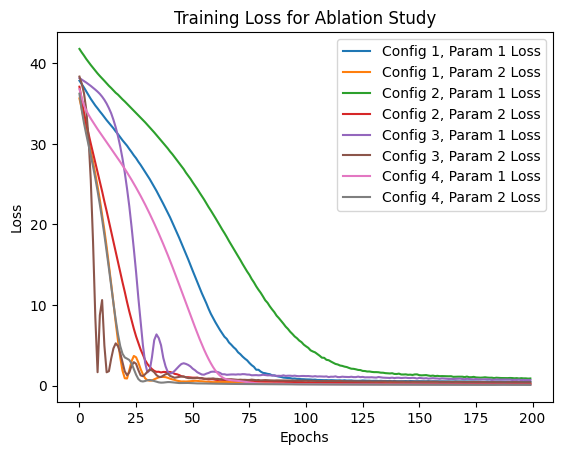

Configuration: Config-1_Param-1
  Architecture: {'use_auxiliary': True, 'use_batchnorm': True, 'use_dropout': True}
  Parameters: {'lr': 0.001, 'weight_decay': 0.0001}
  MSE: 0.2930, R2: 0.8291

Configuration: Config-1_Param-2
  Architecture: {'use_auxiliary': True, 'use_batchnorm': True, 'use_dropout': True}
  Parameters: {'lr': 0.004, 'weight_decay': 0.001}
  MSE: 0.2400, R2: 0.8600

Configuration: Config-2_Param-1
  Architecture: {'use_auxiliary': False, 'use_batchnorm': True, 'use_dropout': True}
  Parameters: {'lr': 0.001, 'weight_decay': 0.0001}
  MSE: 0.4428, R2: 0.7418

Configuration: Config-2_Param-2
  Architecture: {'use_auxiliary': False, 'use_batchnorm': True, 'use_dropout': True}
  Parameters: {'lr': 0.004, 'weight_decay': 0.001}
  MSE: 0.2431, R2: 0.8582

Configuration: Config-3_Param-1
  Architecture: {'use_auxiliary': True, 'use_batchnorm': False, 'use_dropout': True}
  Parameters: {'lr': 0.001, 'weight_decay': 0.0001}
  MSE: 0.4471, R2: 0.7392

Configuration: Config-3_

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Data preparation
# Extract features and labels from the training dataset
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# Standardize features using MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Convert NumPy arrays to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # Add an extra dimension for consistency

# Define the improved MLP model
class ImprovedMLP(nn.Module):
    def __init__(self, input_size, use_auxiliary=True, use_batchnorm=True, use_dropout=True):
        super(ImprovedMLP, self).__init__()

        # Main branch
        layers_main = [
            nn.Linear(input_size, 256),
            nn.LeakyReLU(negative_slope=0.01),
        ]
        if use_batchnorm:
            layers_main.append(nn.BatchNorm1d(256))
        if use_dropout:
            layers_main.append(nn.Dropout(0.4))

        layers_main.extend([
            nn.Linear(256, 128),
            nn.ReLU(),
        ])
        if use_batchnorm:
            layers_main.append(nn.BatchNorm1d(128))
        if use_dropout:
            layers_main.append(nn.Dropout(0.3))

        layers_main.extend([
            nn.Linear(128, 64),
            nn.ReLU(),
        ])
        if use_batchnorm:
            layers_main.append(nn.BatchNorm1d(64))
        if use_dropout:
            layers_main.append(nn.Dropout(0.3))

        layers_main.extend([
            nn.Linear(64, 32),
            nn.ReLU(),
        ])
        if use_batchnorm:
            layers_main.append(nn.BatchNorm1d(32))

        self.main_branch = nn.Sequential(*layers_main)

        # Auxiliary branch
        self.use_auxiliary = use_auxiliary
        if use_auxiliary:
            self.aux_branch = nn.Sequential(
                nn.Linear(input_size, 64),
                nn.ReLU(),
                nn.Dropout(0.2) if use_dropout else nn.Identity(),

                nn.Linear(64, 32),
                nn.ReLU()
            )

        # Output layer
        output_size = 64 if use_auxiliary else 32
        self.output_layer = nn.Sequential(
            nn.Linear(output_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        # Forward pass through the main branch
        main_output = self.main_branch(x)

        if self.use_auxiliary:
            # Forward pass through the auxiliary branch
            aux_output = self.aux_branch(x)

            # Combine main and auxiliary outputs
            combined_output = torch.cat((main_output, aux_output), dim=1)
        else:
            combined_output = main_output

        # Final output
        return self.output_layer(combined_output)

# Ablation study setup
ablation_configs = [
    {'use_auxiliary': True, 'use_batchnorm': True, 'use_dropout': True},
    {'use_auxiliary': False, 'use_batchnorm': True, 'use_dropout': True},
    {'use_auxiliary': True, 'use_batchnorm': False, 'use_dropout': True},
    {'use_auxiliary': True, 'use_batchnorm': True, 'use_dropout': False},
]

# Parameter ablation setup
param_ablation_configs = [
    {'lr': 0.001, 'weight_decay': 1e-4},
    {'lr': 0.004, 'weight_decay': 1e-3},
]

# Iterate through different configurations for ablation
results = {}
for i, config in enumerate(ablation_configs):
    print(f"Running ablation study configuration {i+1}/{len(ablation_configs)}: {config}")

    for j, param_config in enumerate(param_ablation_configs):
        print(f"  Parameter configuration {j+1}/{len(param_ablation_configs)}: {param_config}")

        # Initialize the model
        input_size = X.shape[1]  # Number of input features
        model = ImprovedMLP(input_size, **config)

        # Define loss function and optimizer
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=param_config['lr'], weight_decay=param_config['weight_decay'])

        # Train the model
        num_epochs = 200
        train_losses = []

        for epoch in range(num_epochs):
            model.train()
            outputs = model(X_tensor)
            loss = criterion(outputs, y_tensor)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            if (epoch + 1) % 20 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

        # Evaluate on the test set
        X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
        y_test_true = movies_test_df_selected['vote_average'].values

        X_test = np.array(X_test, dtype=np.float32)
        X_test = scaler.transform(X_test)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

        model.eval()
        with torch.no_grad():
            predictions = model(X_test_tensor).numpy()

        mse = mean_squared_error(y_test_true, predictions)
        r2 = r2_score(y_test_true, predictions)

        # Store results for this configuration
        key = f"Config-{i+1}_Param-{j+1}"
        results[key] = {'config': config, 'params': param_config, 'mse': mse, 'r2': r2}

        # Plot training loss
        plt.plot(train_losses, label=f'Config {i+1}, Param {j+1} Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss for Ablation Study')
plt.show()

# Display results
for config, metrics in results.items():
    print(f"Configuration: {config}")
    print(f"  Architecture: {metrics['config']}")
    print(f"  Parameters: {metrics['params']}")
    print(f"  MSE: {metrics['mse']:.4f}, R2: {metrics['r2']:.4f}\n")


#Attention

Running ablation study configuration 1/3: {'embed_dim': 32, 'num_heads': 2}
Epoch [20/200], Train Loss: 2.3221
Epoch [40/200], Train Loss: 0.7347
Epoch [60/200], Train Loss: 0.5421
Epoch [80/200], Train Loss: 0.4792
Epoch [100/200], Train Loss: 0.4142
Epoch [120/200], Train Loss: 0.3573
Epoch [140/200], Train Loss: 0.3458
Epoch [160/200], Train Loss: 0.3110
Epoch [180/200], Train Loss: 0.2991
Epoch [200/200], Train Loss: 0.2811
Running ablation study configuration 2/3: {'embed_dim': 64, 'num_heads': 4}
Epoch [20/200], Train Loss: 0.6712
Epoch [40/200], Train Loss: 0.6198
Epoch [60/200], Train Loss: 0.5083
Epoch [80/200], Train Loss: 0.4750
Epoch [100/200], Train Loss: 0.4261
Epoch [120/200], Train Loss: 0.3775
Epoch [140/200], Train Loss: 0.3678
Epoch [160/200], Train Loss: 0.3462
Epoch [180/200], Train Loss: 0.3314
Epoch [200/200], Train Loss: 0.3107
Running ablation study configuration 3/3: {'embed_dim': 128, 'num_heads': 8}
Epoch [20/200], Train Loss: 0.8213
Epoch [40/200], Train Lo

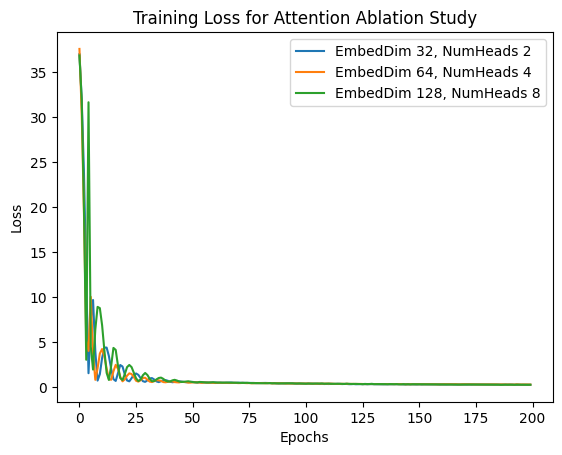

Configuration: EmbedDim-32_NumHeads-2 => MSE: 0.2534, R2: 0.8522
Configuration: EmbedDim-64_NumHeads-4 => MSE: 0.2531, R2: 0.8524
Configuration: EmbedDim-128_NumHeads-8 => MSE: 0.2483, R2: 0.8552


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Data preparation
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# Standardize data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Convert to Tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Define the improved Attention model
class ImprovedAttentionModel(nn.Module):
    def __init__(self, input_size, embed_dim, num_heads, hidden_dim):
        super(ImprovedAttentionModel, self).__init__()

        # Main branch network: Attention for feature extraction
        self.main_attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=0.3, batch_first=True)
        self.main_fc = nn.Sequential(
            nn.Linear(input_size, embed_dim),  # Initial mapping to embed_dim
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )

        # Auxiliary branch network: simple fully connected layers
        self.aux_branch = nn.Sequential(
            nn.Linear(input_size, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Output layer
        self.output_layer = nn.Sequential(
            nn.Linear(embed_dim + hidden_dim, 64),  # Combine main and auxiliary branches
            nn.ReLU(),
            nn.Linear(64, 1)  # Final output
        )

    def forward(self, x):
        # Main branch: use Attention
        x_embedded = self.main_fc(x).unsqueeze(1)  # Add sequence dimension
        main_output, _ = self.main_attention(x_embedded, x_embedded, x_embedded)
        main_output = main_output.squeeze(1)  # Remove sequence dimension

        # Auxiliary branch
        aux_output = self.aux_branch(x)

        # Combine main and auxiliary outputs
        combined_output = torch.cat((main_output, aux_output), dim=1)

        # Process with output layer
        return self.output_layer(combined_output)

# Ablation study setup
ablation_configs = [
    {'embed_dim': 32, 'num_heads': 2},
    {'embed_dim': 64, 'num_heads': 4},
    {'embed_dim': 128, 'num_heads': 8},
]

hidden_dim = 256  # Fixed auxiliary branch hidden dimension
results = {}

for i, config in enumerate(ablation_configs):
    print(f"Running ablation study configuration {i+1}/{len(ablation_configs)}: {config}")

    # Initialize the model
    input_size = X.shape[1]  # Number of input features
    model = ImprovedAttentionModel(input_size, config['embed_dim'], config['num_heads'], hidden_dim)

    # Define loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    # Train the model
    num_epochs = 200
    train_losses = []

    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

    # Evaluate on the test set
    X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
    y_test_true = movies_test_df_selected['vote_average'].values

    X_test = np.array(X_test, dtype=np.float32)
    X_test = scaler.transform(X_test)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        predictions = model(X_test_tensor).numpy()

    mse = mean_squared_error(y_test_true, predictions)
    r2 = r2_score(y_test_true, predictions)

    # Store results for this configuration
    key = f"EmbedDim-{config['embed_dim']}_NumHeads-{config['num_heads']}"
    results[key] = {'mse': mse, 'r2': r2}

    # Plot training loss
    plt.plot(train_losses, label=f"EmbedDim {config['embed_dim']}, NumHeads {config['num_heads']}")

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss for Attention Ablation Study')
plt.show()

# Display results
for config, metrics in results.items():
    print(f"Configuration: {config} => MSE: {metrics['mse']:.4f}, R2: {metrics['r2']:.4f}")


#Machine Learning

Running ablation study configuration 1/3: {'alpha_1': 1e-06, 'alpha_2': 1e-06, 'lambda_1': 1e-06, 'lambda_2': 1e-06}
Running ablation study configuration 2/3: {'alpha_1': 1e-05, 'alpha_2': 1e-05, 'lambda_1': 1e-05, 'lambda_2': 1e-05}
Running ablation study configuration 3/3: {'alpha_1': 0.0001, 'alpha_2': 0.0001, 'lambda_1': 0.0001, 'lambda_2': 0.0001}


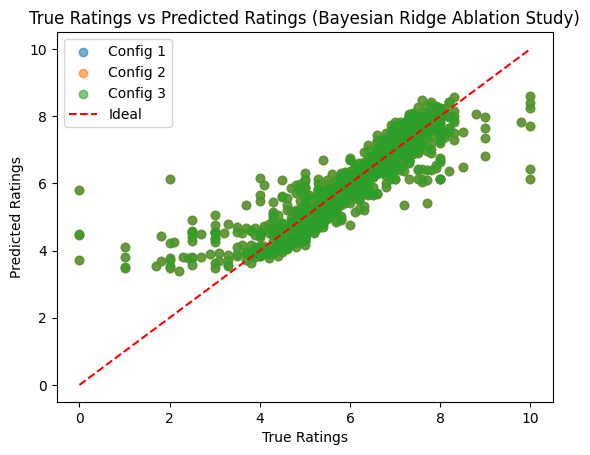

Configuration: {'alpha_1': 1e-06, 'alpha_2': 1e-06, 'lambda_1': 1e-06, 'lambda_2': 1e-06}
  MSE: 0.3924, R2: 0.7711

Configuration: {'alpha_1': 1e-05, 'alpha_2': 1e-05, 'lambda_1': 1e-05, 'lambda_2': 1e-05}
  MSE: 0.3924, R2: 0.7711

Configuration: {'alpha_1': 0.0001, 'alpha_2': 0.0001, 'lambda_1': 0.0001, 'lambda_2': 0.0001}
  MSE: 0.3924, R2: 0.7711



In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Data preparation
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# Standardize data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Ablation study setup
ablation_configs = [
    {'alpha_1': 1e-6, 'alpha_2': 1e-6, 'lambda_1': 1e-6, 'lambda_2': 1e-6},
    {'alpha_1': 1e-5, 'alpha_2': 1e-5, 'lambda_1': 1e-5, 'lambda_2': 1e-5},
    {'alpha_1': 1e-4, 'alpha_2': 1e-4, 'lambda_1': 1e-4, 'lambda_2': 1e-4},
]

results = {}

for i, config in enumerate(ablation_configs):
    print(f"Running ablation study configuration {i+1}/{len(ablation_configs)}: {config}")

    # Initialize Bayesian Ridge regression model
    model = BayesianRidge(
        alpha_1=config['alpha_1'],
        alpha_2=config['alpha_2'],
        lambda_1=config['lambda_1'],
        lambda_2=config['lambda_2']
    )

    # Train the model
    model.fit(X, y)

    # Predict on training set
    train_predictions = model.predict(X)

    # Test the model
    X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
    y_test_true = movies_test_df_selected['vote_average'].values

    # Convert to NumPy arrays and standardize
    X_test = np.array(X_test, dtype=np.float32)
    X_test = scaler.transform(X_test)

    # Predict on test set
    test_predictions = model.predict(X_test)

    # Compute metrics
    mse = mean_squared_error(y_test_true, test_predictions)
    r2 = r2_score(y_test_true, test_predictions)

    # Store results for this configuration
    results[str(config)] = {'mse': mse, 'r2': r2}

    # Visualize true vs predicted ratings
    plt.scatter(y_test_true, test_predictions, alpha=0.6, label=f"Config {i+1}")

plt.plot([0, 10], [0, 10], 'r--', label='Ideal')  # Reference line
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings (Bayesian Ridge Ablation Study)')
plt.legend()
plt.show()

# Display results
for config, metrics in results.items():
    print(f"Configuration: {config}")
    print(f"  MSE: {metrics['mse']:.4f}, R2: {metrics['r2']:.4f}\n")


Running ablation study configuration 1/4: {'C': 0.1, 'epsilon': 0.1}
Running ablation study configuration 2/4: {'C': 1.0, 'epsilon': 0.2}
Running ablation study configuration 3/4: {'C': 10.0, 'epsilon': 0.6}
Running ablation study configuration 4/4: {'C': 100.0, 'epsilon': 0.6}


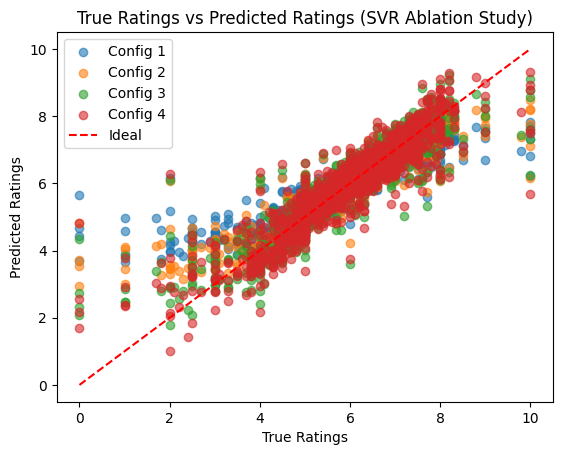

Configuration: {'C': 0.1, 'epsilon': 0.1}
  MSE: 0.4150, R2: 0.7580

Configuration: {'C': 1.0, 'epsilon': 0.2}
  MSE: 0.2726, R2: 0.8410

Configuration: {'C': 10.0, 'epsilon': 0.6}
  MSE: 0.2709, R2: 0.8420

Configuration: {'C': 100.0, 'epsilon': 0.6}
  MSE: 0.2956, R2: 0.8276



In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Data preparation
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# Standardize data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Ablation study setup
ablation_configs = [
    {'C': 0.1, 'epsilon': 0.1},
    {'C': 1.0, 'epsilon': 0.2},
    {'C': 10.0, 'epsilon': 0.6},
    {'C': 100.0, 'epsilon': 0.6},
]

results = {}

for i, config in enumerate(ablation_configs):
    print(f"Running ablation study configuration {i+1}/{len(ablation_configs)}: {config}")

    # Initialize Support Vector Regression model
    model = SVR(kernel='rbf', C=config['C'], epsilon=config['epsilon'])

    # Train the model
    model.fit(X, y)

    # Predict on training set
    train_predictions = model.predict(X)

    # Test the model
    X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
    y_test_true = movies_test_df_selected['vote_average'].values

    # Convert to NumPy arrays and standardize
    X_test = np.array(X_test, dtype=np.float32)
    X_test = scaler.transform(X_test)

    # Predict on test set
    test_predictions = model.predict(X_test)

    # Compute metrics
    mse = mean_squared_error(y_test_true, test_predictions)
    r2 = r2_score(y_test_true, test_predictions)

    # Store results for this configuration
    results[str(config)] = {'mse': mse, 'r2': r2}

    # Visualize true vs predicted ratings
    plt.scatter(y_test_true, test_predictions, alpha=0.6, label=f"Config {i+1}")

plt.plot([0, 10], [0, 10], 'r--', label='Ideal')  # Reference line
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings (SVR Ablation Study)')
plt.legend()
plt.show()

# Display results
for config, metrics in results.items():
    print(f"Configuration: {config}")
    print(f"  MSE: {metrics['mse']:.4f}, R2: {metrics['r2']:.4f}\n")


Running ablation study configuration 1/4: {'n_estimators': 50, 'max_depth': 10}
Running ablation study configuration 2/4: {'n_estimators': 100, 'max_depth': 20}
Running ablation study configuration 3/4: {'n_estimators': 200, 'max_depth': 30}
Running ablation study configuration 4/4: {'n_estimators': 300, 'max_depth': None}


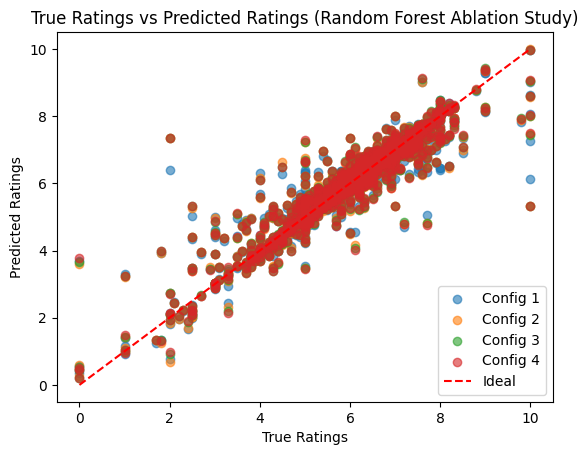

Configuration: {'n_estimators': 50, 'max_depth': 10}
  MSE: 0.1885, R2: 0.8900

Configuration: {'n_estimators': 100, 'max_depth': 20}
  MSE: 0.2051, R2: 0.8804

Configuration: {'n_estimators': 200, 'max_depth': 30}
  MSE: 0.2050, R2: 0.8804

Configuration: {'n_estimators': 300, 'max_depth': None}
  MSE: 0.2064, R2: 0.8796



In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Data preparation
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# Standardize data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Ablation study setup
ablation_configs = [
    {'n_estimators': 50, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 200, 'max_depth': 30},
    {'n_estimators': 300, 'max_depth': None},
]

results = {}

for i, config in enumerate(ablation_configs):
    print(f"Running ablation study configuration {i+1}/{len(ablation_configs)}: {config}")

    # Initialize Random Forest Regressor
    model = RandomForestRegressor(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        random_state=42
    )

    # Train the model
    model.fit(X, y)

    # Predict on training set
    train_predictions = model.predict(X)

    # Test the model
    X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
    y_test_true = movies_test_df_selected['vote_average'].values

    # Convert to NumPy arrays and standardize
    X_test = np.array(X_test, dtype=np.float32)
    X_test = scaler.transform(X_test)

    # Predict on test set
    test_predictions = model.predict(X_test)

    # Compute metrics
    mse = mean_squared_error(y_test_true, test_predictions)
    r2 = r2_score(y_test_true, test_predictions)

    # Store results for this configuration
    results[str(config)] = {'mse': mse, 'r2': r2}

    # Visualize true vs predicted ratings
    plt.scatter(y_test_true, test_predictions, alpha=0.6, label=f"Config {i+1}")

plt.plot([0, 10], [0, 10], 'r--', label='Ideal')  # Reference line
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings (Random Forest Ablation Study)')
plt.legend()
plt.show()

# Display results
for config, metrics in results.items():
    print(f"Configuration: {config}")
    print(f"  MSE: {metrics['mse']:.4f}, R2: {metrics['r2']:.4f}\n")
